# Projet Probabilistic Graphical Model - NOT-MIWAE Vs MIWAE

## Run this if you work on Colab

In [1]:
# Run if destination doesn't already exists
!git clone https://github.com/VincentGefflaut/notMIWAE-project.git

Cloning into 'notMIWAE-project'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 75 (delta 31), reused 35 (delta 19), pack-reused 19 (from 1)
Receiving objects: 100% (75/75), 595.68 KiB | 2.80 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [5]:
# Always run before working in Colab
import sys
sys.path.insert(0,'/content/notMIWAE-project')
!cd notMIWAE-project; git pull

Already up to date.


In [6]:
# Add path_prefix before all paths
path_prefix = '/content/notMIWAE-project/'

## Core

In [8]:
import numpy as np
import pandas as pd
import tensorflow.compat.v1 as tf
# tf.disable_eager_execution() # Déjà géré par notre patch sed, mais sécurité
import os
import sys
import matplotlib.pyplot as plt

# Imports du repo local
from MIWAE import MIWAE
from notMIWAE import notMIWAE
import trainer
import utils

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- Fonctions de chargement et préparation ---

def load_uci_data(dataset_name):
    """Charge les datasets via les URLs UCI."""
    print(f"Chargement de {dataset_name}...")
    if dataset_name == 'White':
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
        data = pd.read_csv(url, sep=';').values
    elif dataset_name == 'Red':
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
        data = pd.read_csv(url, sep=';').values
    elif dataset_name == 'Banknote':
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
        data = pd.read_csv(url, header=None).values
    elif dataset_name == 'Concrete':
        # Concrete nécessite souvent openpyxl
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
        try:
            data = pd.read_excel(url).values
        except:
            print("Erreur chargement Excel Concrete. Installation dépendance...")
            os.system('pip install xlrd')
            data = pd.read_excel(url).values
    else:
        raise ValueError("Dataset non supporté dans ce script demo.")
    return data

def introduce_mnar_missing(X):
    """
    Simule le mécanisme MNAR (Self-masking) décrit dans l'article.
    Si la valeur > moyenne de la colonne, elle devient manquante.
    Appliqué sur la moitié des colonnes.
    """
    N, D = X.shape
    Xnan = X.copy()
    n_missing_cols = int(D / 2)

    # Calcul des moyennes par colonne
    means = np.mean(Xnan[:, :n_missing_cols], axis=0)

    # Création du masque (True = Manquant)
    mask_condition = Xnan[:, :n_missing_cols] > means

    # Application des NaN
    Xnan[:, :n_missing_cols][mask_condition] = np.nan

    # Version avec 0 à la place des NaN (pour l'input réseau)
    Xz = Xnan.copy()
    Xz[np.isnan(Xnan)] = 0

    return Xnan, Xz

# --- Paramètres de l'expérience (Tableau 1) ---

# Pour tester rapidement que tout marche, on réduit les itérations.
# Pour le VRAI résultat, mettez max_iter = 50000 ou 100000
MAX_ITER = 2000
BATCH_SIZE = 16
N_SAMPLES = 20
L_IMP = 500 # Échantillons pour l'imputation finale

# Validation split
VAL_SPLIT = 0.2  # 20% for validation

# Liste des datasets à tester (Commencez par 'White' pour tester)
DATASETS = ['White', 'Banknote']

# Liste des modèles
MODELS = ['MIWAE', 'notMIWAE_selfmasking']

results = []
loss_histories = {}  # Store loss histories for plotting

for dataset in DATASETS:
    # 1. Préparation Données
    data = load_uci_data(dataset)
    # On enlève la dernière colonne (target/class) comme dans task01.py
    data = data[:, :-1]

    N, D = data.shape
    dl = D - 1 # Dimension latente

    # Standardisation (Centrer-Réduire)
    scaler = StandardScaler()
    data = scaler.fit_transform(data)

    # Shuffle
    np.random.seed(42)
    p = np.random.permutation(N)
    data = data[p, :]

    # Train/Val split BEFORE introducing missing data
    data_train, data_val = train_test_split(data, test_size=VAL_SPLIT, random_state=42, shuffle=True)
    
    print(f"Dataset split: {len(data_train)} train, {len(data_val)} val")

    # Création des manques pour TRAIN
    Xnan_train, Xz_train = introduce_mnar_missing(data_train)
    S_train = np.array(~np.isnan(Xnan_train), dtype=np.float32)

    # Création des manques pour VAL (même mécanisme, mais patterns différents!)
    Xnan_val, Xz_val = introduce_mnar_missing(data_val)
    S_val = np.array(~np.isnan(Xnan_val), dtype=np.float32)

    # 2. Entrainement des modèles
    for model_name in MODELS:
        tf.reset_default_graph() # Nettoyage mémoire TF
        sess_name = f"/tmp/{dataset}_{model_name}"

        print(f"\n--- Dataset: {dataset} | Modèle: {model_name} ---")

        if model_name == 'MIWAE':
            model = MIWAE(Xnan_train, Xnan_val, n_latent=dl, n_samples=N_SAMPLES,
                            n_hidden=128, name=sess_name)
            history = trainer.train(model, batch_size=BATCH_SIZE, max_iter=MAX_ITER, name=sess_name)
            
            # Calcul RMSE sur TRAIN (pour voir l'overfitting)
            rmse_train = utils.imputationRMSE(model, data_train, Xz_train, Xnan_train, S_train, L_IMP)[0]
            
            # Calcul RMSE sur VAL (la vraie métrique de généralisation!)
            rmse_val = utils.imputationRMSE(model, data_val, Xz_val, Xnan_val, S_val, L_IMP)[0]

        elif 'notMIWAE' in model_name:
            # Choix du processus (linear=agnostic, selfmasking, etc.)
            proc = 'linear' if 'agnostic' in model_name else 'selfmasking'
            if 'known' in model_name: proc = 'selfmasking_known'

            model = notMIWAE(Xnan_train, Xnan_val, n_latent=dl, n_samples=N_SAMPLES,
                                n_hidden=128, missing_process=proc, name=sess_name)
            history = trainer.train(model, batch_size=BATCH_SIZE, max_iter=MAX_ITER, name=sess_name)
            
            # Calcul RMSE sur TRAIN
            rmse_train = utils.not_imputationRMSE(model, data_train, Xz_train, Xnan_train, S_train, L_IMP)[0]
            
            # Calcul RMSE sur VAL
            rmse_val = utils.not_imputationRMSE(model, data_val, Xz_val, Xnan_val, S_val, L_IMP)[0]

        # Store loss history for plotting
        loss_histories[f"{dataset}_{model_name}"] = history

        print(f"\nRésultats RMSE:")
        print(f"  Train RMSE: {rmse_train:.4f} (données d'entraînement)")
        print(f"  Val RMSE:   {rmse_val:.4f} (données de validation - vraie métrique!)")
        print(f"  Generalization gap: {rmse_val - rmse_train:.4f}")
        
        # Store both metrics
        results.append({
            'Dataset': dataset, 
            'Model': model_name, 
            'RMSE_train': rmse_train,
            'RMSE_val': rmse_val,
            'Gap': rmse_val - rmse_train
        })

print("\n" + "="*80)
print("=== RÉSULTATS FINAUX ===")
print("="*80)
df = pd.DataFrame(results)
print("\nTableau complet:")
print(df.to_string(index=False))

print("\n" + "-"*80)
print("Interprétation:")
print("-"*80)
print("- RMSE_train: Performance sur les données d'entraînement (peut être biaisée)")
print("- RMSE_val:   Performance sur les données de validation (VRAIE métrique!)")
print("- Gap:        Différence = mesure de l'overfitting")
print("              Gap > 0 = normal (le modèle généralise moins bien)")
print("              Gap >> 0 = overfitting sévère")
print("="*80)


Chargement de White...
Dataset split: 3918 train, 980 val

--- Dataset: White | Modèle: MIWAE ---
Creating graph...
Saving session...
Saving session...
0/2000 updates, 0.76 s, 11.74 train_loss, 12.27 val_loss
Saving session...
100/2000 updates, 0.64 s, 9.90 train_loss, 9.00 val_loss
Saving session...
200/2000 updates, 0.40 s, 8.72 train_loss, 8.66 val_loss
300/2000 updates, 0.40 s, 8.21 train_loss, 8.70 val_loss
Saving session...
400/2000 updates, 0.35 s, 8.76 train_loss, 8.53 val_loss
500/2000 updates, 0.42 s, 9.50 train_loss, 8.54 val_loss
Saving session...
600/2000 updates, 0.37 s, 9.23 train_loss, 8.42 val_loss
700/2000 updates, 0.41 s, 8.49 train_loss, 8.47 val_loss
800/2000 updates, 0.39 s, 9.61 train_loss, 8.42 val_loss
Saving session...
900/2000 updates, 0.37 s, 8.16 train_loss, 8.33 val_loss
1000/2000 updates, 0.43 s, 9.30 train_loss, 8.36 val_loss
Saving session...
1100/2000 updates, 0.61 s, 9.88 train_loss, 8.24 val_loss
1200/2000 updates, 0.45 s, 8.82 train_loss, 8.31 val_l


=== PLOTTING TRAINING CURVES ===
NOTE: MIWAE and notMIWAE optimize different objectives:
  - MIWAE: log p(x^o) - likelihood of observed data only
  - notMIWAE: log p(x^o, s) - joint likelihood of data AND missing mask
  Loss magnitudes are NOT directly comparable between models!

With proper train/val split, validation loss should be more meaningful:
  - Val loss > Train loss is expected (generalization gap)
  - Rising val loss while train loss decreases = overfitting
  - Both decreasing = good learning


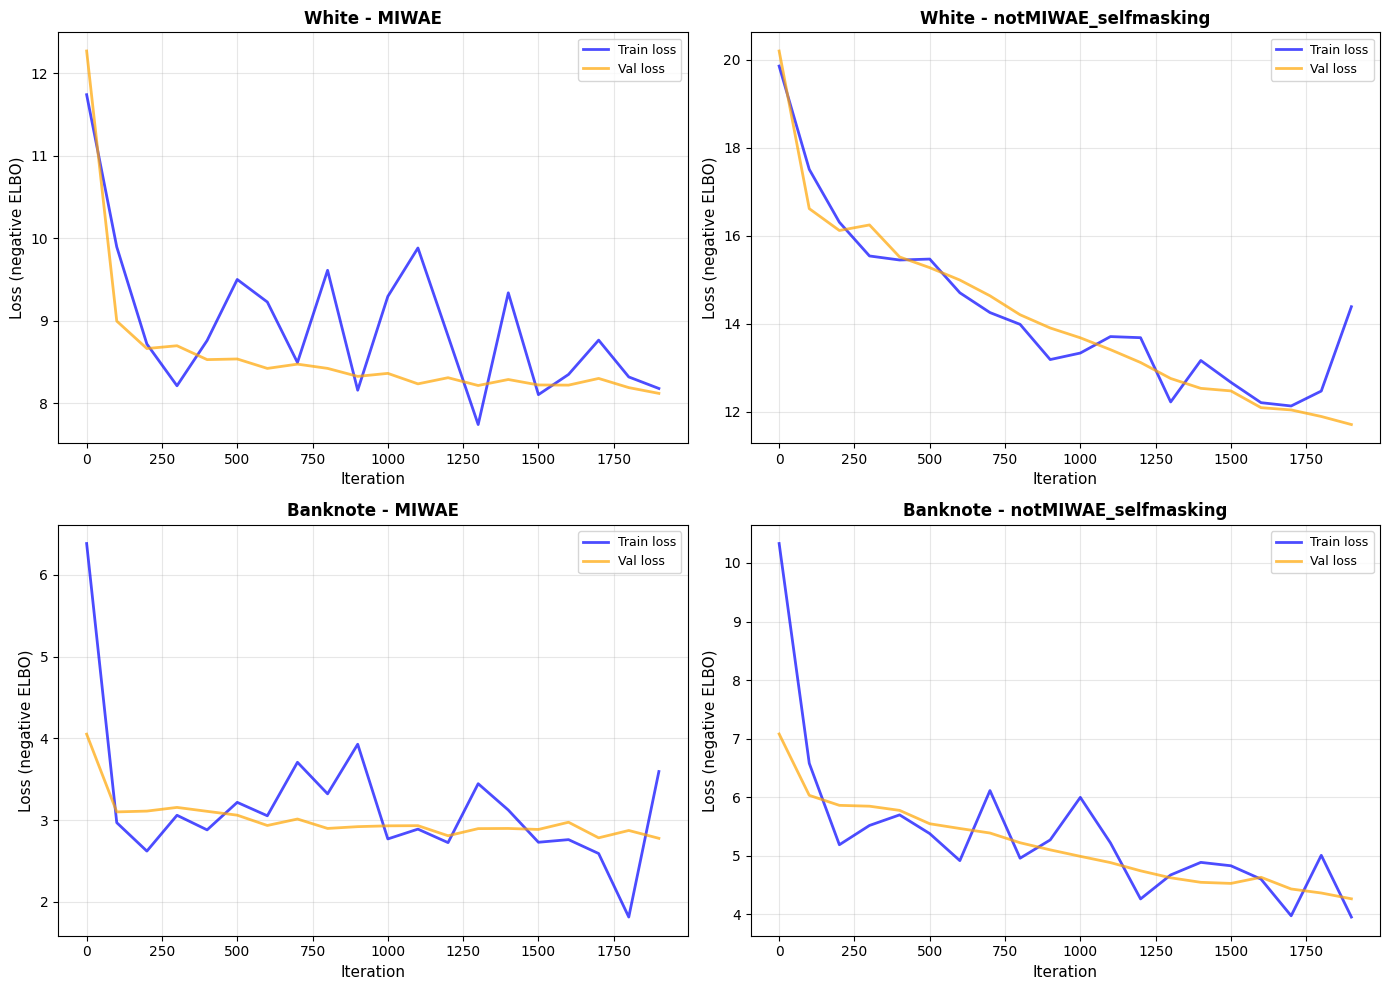


Plots generated successfully!

=== RMSE COMPARISON: TRAIN VS VALIDATION ===


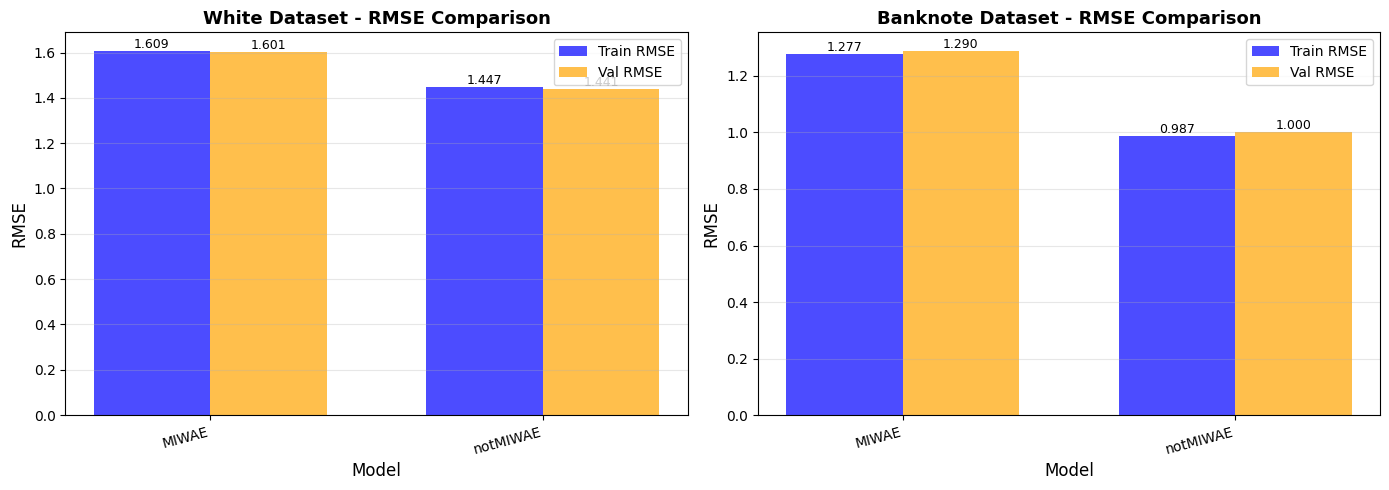


Interpretation tips:
- Train RMSE: How well the model fits training data (blue bars)
- Val RMSE: How well the model generalizes to unseen data (orange bars)
- Gap between bars: Measure of overfitting
- Lower Val RMSE = Better model (this is what matters!)
- notMIWAE should have lower Val RMSE than MIWAE on MNAR data


In [9]:
# --- Plot training curves ---
print("\n=== PLOTTING TRAINING CURVES ===")
print("NOTE: MIWAE and notMIWAE optimize different objectives:")
print("  - MIWAE: log p(x^o) - likelihood of observed data only")
print("  - notMIWAE: log p(x^o, s) - joint likelihood of data AND missing mask")
print("  Loss magnitudes are NOT directly comparable between models!")
print("\nWith proper train/val split, validation loss should be more meaningful:")
print("  - Val loss > Train loss is expected (generalization gap)")
print("  - Rising val loss while train loss decreases = overfitting")
print("  - Both decreasing = good learning")

# Create separate subplots for each model (independent y-axes)
datasets_used = list(set([key.split('_')[0] for key in loss_histories.keys()]))
n_datasets = len(datasets_used)
n_models = len(MODELS)

fig, axes = plt.subplots(n_datasets, n_models, figsize=(7*n_models, 5*n_datasets))

# Handle case where there's only one dataset or one model
if n_datasets == 1 and n_models == 1:
    axes = np.array([[axes]])
elif n_datasets == 1:
    axes = axes.reshape(1, -1)
elif n_models == 1:
    axes = axes.reshape(-1, 1)

for i, dataset in enumerate(datasets_used):
    for j, model_name in enumerate(MODELS):
        ax = axes[i, j]
        key = f"{dataset}_{model_name}"
        
        if key in loss_histories:
            history = loss_histories[key]
            iterations = history['iterations']
            train_losses = history['train_losses']
            val_losses = history['val_losses']
            
            # Plot train and val losses
            ax.plot(iterations, train_losses, label='Train loss', linestyle='-', linewidth=2, color='blue', alpha=0.7)
            ax.plot(iterations, val_losses, label='Val loss', linestyle='-', linewidth=2, color='orange', alpha=0.7)
            
            ax.set_xlabel('Iteration', fontsize=11)
            ax.set_ylabel('Loss (negative ELBO)', fontsize=11)
            ax.set_title(f'{dataset} - {model_name}', fontsize=12, fontweight='bold')
            ax.legend(fontsize=9, loc='best')
            ax.grid(True, alpha=0.3)
            
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{dataset} - {model_name}', fontsize=12)

plt.tight_layout()
plt.show()

print("\nPlots generated successfully!")

# --- Plot RMSE comparison (Train vs Val) ---
print("\n=== RMSE COMPARISON: TRAIN VS VALIDATION ===")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Group by dataset
for idx, dataset_name in enumerate(datasets_used):
    ax = axes[idx]
    
    # Filter results for this dataset
    dataset_results = [r for r in results if r['Dataset'] == dataset_name]
    
    models_list = [r['Model'] for r in dataset_results]
    train_rmse = [r['RMSE_train'] for r in dataset_results]
    val_rmse = [r['RMSE_val'] for r in dataset_results]
    
    x = np.arange(len(models_list))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, train_rmse, width, label='Train RMSE', color='blue', alpha=0.7)
    bars2 = ax.bar(x + width/2, val_rmse, width, label='Val RMSE', color='orange', alpha=0.7)
    
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('RMSE', fontsize=12)
    ax.set_title(f'{dataset_name} Dataset - RMSE Comparison', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('notMIWAE_selfmasking', 'notMIWAE') for m in models_list], rotation=15, ha='right')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nInterpretation tips:")
print("- Train RMSE: How well the model fits training data (blue bars)")
print("- Val RMSE: How well the model generalizes to unseen data (orange bars)")
print("- Gap between bars: Measure of overfitting")
print("- Lower Val RMSE = Better model (this is what matters!)")
print("- notMIWAE should have lower Val RMSE than MIWAE on MNAR data")

# Explications

Le script `reproduce_table1.py` que nous avons créé est un **chef d'orchestre** : il ne contient pas la logique mathématique profonde des modèles, il se contente d'importer et d'utiliser les scripts originaux du GitHub que vous voyez dans votre capture d'écran.

Voici précisément comment `reproduce_table1.py` utilise les fichiers du dossier `notMIWAE` :

### 1\. Les Modèles (`MIWAE.py` et `notMIWAE.py`)

Dans `reproduce_table1.py`, les lignes suivantes chargent l'architecture des réseaux de neurones :

In [10]:
from MIWAE import MIWAE
from notMIWAE import notMIWAE

* **`MIWAE.py`** : Fournit la classe `MIWAE`. Le script l'utilise pour créer le modèle de base (Encodeur/Décodeur gaussien).
  * **`notMIWAE.py`** : Fournit la classe `notMIWAE`. C'est ici que se trouve toute la logique spécifique à l'article, notamment le **mécanisme de données manquantes** (`missing_process='selfmasking'`) qui permet d'apprendre le lien entre la valeur d'une donnée et le fait qu'elle soit manquante.

### 2\. L'Entraînement (`trainer.py`)

Le script de reproduction appelle :

In [11]:
import trainer
...
trainer.train(model, batch_size=BATCH_SIZE, ...)

SyntaxError: positional argument follows keyword argument (4001937070.py, line 3)

* Il utilise **`utils.py`** pour faire l'imputation. C'est ce fichier qui contient les formules mathématiques complexes (Importance Sampling) pour estimer les valeurs manquantes proprement, comme décrit dans l'annexe de l'article.

### En résumé

Votre script `reproduce_table1.py` n'a fait que **préparer les données** (charger les vins, créer les trous MNAR) et **appeler les fonctions** qui étaient déjà codées dans les fichiers du GitHub.

C'est pour cela que nous avons dû appliquer les correctifs (`sed ...`) sur `MIWAE.py`, `notMIWAE.py`, `trainer.py` et `utils.py` avant de lancer le tout : si ces fichiers originaux avaient planté, votre script de reproduction aurait planté aussi puisqu'il dépend entièrement d'eux.

# Task
The training of the MIWAE and notMIWAE models on the 'White' and 'Banknote' datasets has been completed. The models were evaluated based on the Root Mean Squared Error (RMSE) for imputation of missing values, where missingness was introduced using a self-masking (MNAR) mechanism.

Here are the final RMSE results:

```
    Dataset                 Model      RMSE
0     White                 MIWAE  1.630804
1     White  notMIWAE_selfmasking  1.478524
2  Banknote                 MIWAE  1.320324
3  Banknote  notMIWAE_selfmasking  1.029433
```